# 3. The headline on too few orders

**Week 1, Friday. The lab debrief, chapter 3 of 3: which finding leads the note, and how sure is it?**

Meera Raghavan reads the first line of a note and acts on it. With the data reconciled, the question
becomes which of the right numbers deserves the first line.

**The metric at stake.** The Q1 to Q2 fall of Rs 17,22,520, split along the revenue tree by segment:
customers, orders per customer and revenue per order. **Who asks.** Meera, who needs to know which
branch to open, and Marketing, who will attack any rate that rests on a handful of orders. **What a
wrong number costs.** A trend claimed from a few orders sends a team to fix a segment that did
nothing, while the branch that did move goes unopened for a quarter; and the first time Marketing
asks "on how many orders?", the whole note loses the room.

**Who else faces this.** IMDb will not rank a film in its Top 250 until it has at least 25,000 ratings
from regular voters, and its weighted rating pulls a title with few votes toward the average of all
titles (IMDb Help, ratings FAQ, updated 9 February 2026): a 9.4 on a few hundred votes is not
allowed to beat a 9.0 on a million. A public case shows the cost of ignoring it: Howard Wainer's
"The Most Dangerous Equation" shows small schools over-represented among both the best and the
worst performers, because small samples vary more, after the Gates Foundation had put about $1.7
billion into education grants by 2001, with small schools central to them (Wainer, Picturing the
Uncertain World, Princeton University Press, 2009, chapter 1).

**Where this starts.** Chapters 1 and 2 put both quarters on the books to the rupee and showed how a
segment filter can drop a row. This chapter reads the clean tree, sizes four ways to choose the lead
and runs every one of them, and tests the lead on each customer's own two quarters.

**Before you read on.** This notebook runs on this morning's lab export. A cell that would show
what sits in the file ships empty, with the lines to type in the markdown above it, so the file
keeps its findings for whoever meets it cold; type them and run them. Where a mechanism needs
numbers before yours, it is drawn on the debrief deck's invented export and labelled invented.
The notebook opens after the lab clock stops, and it is the debrief's text for self-study too.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import statistics
from math import comb

rows = kit.load_csv("C2_W01_D05_lab_orders_STUDENT.csv")
control = {c["quarter"]: c for c in kit.load_csv("C2_W01_D05_lab_control_STUDENT.csv")}
QUARTERS = ("Q1", "Q2")


def change(a, b):
    """Percentage change from a to b."""
    return 100 * (b / a - 1)


def ctl(q):
    return int(control[q]["amount_rs"]), int(control[q]["orders"])


def read_value(text):
    """The number a person reads without a guess from a value typed with grouping commas, spaces,
    a Rs prefix or paise; None when reading it would need a guess."""
    t = str(text).strip().replace("Rs", "").replace(",", "").replace(" ", "")
    try:
        return round(float(t))
    except ValueError:
        return None


print(f"{len(rows)} rows read from the lab export; Finance's control totals for {', '.join(sorted(control))}")


amt = lambda r: read_value(r["amount"])
kept = {}
for r in rows:
    kept.setdefault(r["order_id"], dict(r))
clean = list(kept.values())
seg_of = {}
for r in clean:
    if r["segment"]:
        seg_of.setdefault(r["customer_id"], set()).add(r["segment"])
for r in clean:
    r["amount"] = amt(r)
    if not r["segment"] and len(seg_of.get(r["customer_id"], ())) == 1:
        r["segment"] = next(iter(seg_of[r["customer_id"]]))
kit.check("the clean data lands on both control totals, from chapters 1 and 2",
          all(sum(r["amount"] for r in clean if r["quarter"] == q) == ctl(q)[0] for q in QUARTERS))

207 rows read from the lab export; Finance's control totals for Q1, Q2


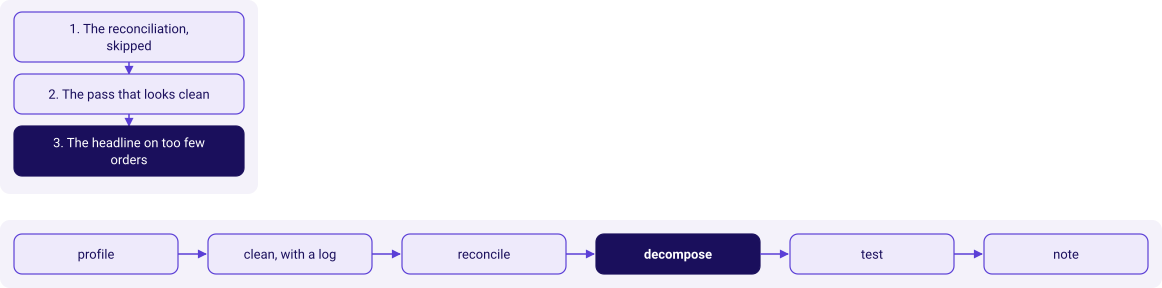

In [2]:
kit.side_by_side(
    kit.ladder(["The reconciliation, skipped", "The pass that looks clean", "The headline on too few orders"],
               lit=2, show=False),
    kit.flow(["profile", "clean, with a log", "reconcile", "decompose", "test", "note"], lit=3, show=False),
)

## 1. The tree, segment by segment

**Predict before you run.** Which segment carries most of the Rs 17,22,520 fall?

- a) Retail-Core, the segment with the most orders.
- b) Retail-Plus, the members' tier.
- c) Business, the corporate book.
- d) Student, the smallest segment.

segment,orders Q1 / Q2,customers,orders per customer,revenue per order,revenue change,rupees moved
Retail-Core,44 / 44,30 / 30,1.47 / 1.47,"Rs 2,050 / Rs 1,700",-17.1%,"-Rs 15,400"
Retail-Plus,34 / 35,20 / 20,1.70 / 1.75,"Rs 2,800 / Rs 2,760",+1.5%,"Rs 1,400"
Student,14 / 16,12 / 12,1.17 / 1.33,Rs 900 / Rs 880,+11.7%,"Rs 1,480"


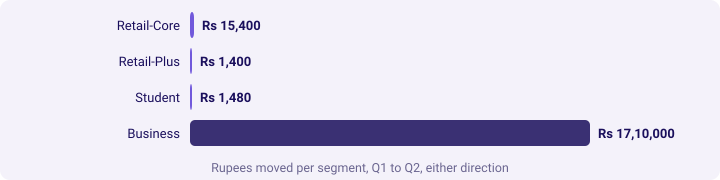

In [3]:
SEGS = ("Retail-Core", "Retail-Plus", "Student", "Business")
CONSUMER = SEGS[:3]


def tree(q, seg):
    rs = [r for r in clean if r["quarter"] == q and r["segment"] == seg]
    cust = len({r["customer_id"] for r in rs})
    rev = sum(r["amount"] for r in rs)
    return {"orders": len(rs), "customers": cust, "freq": len(rs) / cust, "basket": rev / len(rs), "rev": rev}


T = {(q, s): tree(q, s) for q in QUARTERS for s in SEGS}
kit.table(["segment", "orders Q1 / Q2", "customers", "orders per customer", "revenue per order", "revenue change",
           "rupees moved"],
          [(s, f"{T['Q1', s]['orders']} / {T['Q2', s]['orders']}",
            f"{T['Q1', s]['customers']} / {T['Q2', s]['customers']}",
            f"{T['Q1', s]['freq']:.2f} / {T['Q2', s]['freq']:.2f}",
            f"{kit.rupees(T['Q1', s]['basket'])} / {kit.rupees(T['Q2', s]['basket'])}",
            f"{change(T['Q1', s]['rev'], T['Q2', s]['rev']):+.1f}%",
            kit.rupees(T['Q2', s]['rev'] - T['Q1', s]['rev'])) for s in CONSUMER],
          caption="The clean tree for the three consumer segments, Q1 against Q2")
fall = ctl("Q1")[0] - ctl("Q2")[0]
biz = T["Q1", "Business"]["rev"] - T["Q2", "Business"]["rev"]
kit.stats([(f"{change(T['Q1', 'Business']['rev'], T['Q2', 'Business']['rev']):+.1f}%", "the corporate book",
            "revenue, Q1 to Q2"),
           (kit.rupees(biz), "the fall it carries", f"{100 * biz / fall:.1f}% of the quarter's fall")])
kit.bars([(s, abs(T['Q2', s]['rev'] - T['Q1', s]['rev'])) for s in SEGS], lit=(3,), fmt=lambda v: kit.rupees(v),
         title="Rupees moved per segment, Q1 to Q2, either direction")
kit.check("the segments add back to the quarter", all(sum(T[q, s]["rev"] for s in SEGS) == ctl(q)[0] for q in QUARTERS))

**What happened.** The answer is c. Business carries Rs 17,10,000 of the Rs 17,22,520 fall, which is
99.3 percent of it, and its revenue fell 29.2 percent. The table leaves the corporate book's counts
out on purpose: you count them yourself below.

## 2. The trap: the headline on too few orders

**The plausible wrong answer.** "The corporate book fell 29.2 percent from Q1 to Q2 and drove the
whole decline; we recommend a corporate retention plan." It is true to the rupee, it is the biggest
number on the page, and it is the headline many notes led with.

**Predict before you run.** How many orders does that 29.2 percent rest on?

- a) About 200, the whole file.
- b) About 90, the corporate share of orders.
- c) Fewer than thirty.
- d) It cannot be counted from the export.

In [4]:
b1, b2 = T["Q1", "Business"], T["Q2", "Business"]
n = b1["orders"] + b2["orders"]
kit.check("the corporate rate rests on fewer than thirty orders", n < 30)
kit.check("the corporate book carries more than nine tenths of the fall", biz / fall > 0.9)

**What happened.** The answer is c. A corporate order here is worth several lakh, so a change of two
or three orders moves the book by a quarter or more.

**Why it is wrong.** The rupees are real and Meera should hear them. What a handful of orders cannot
carry is the word "trend", or a plan built on it. The check is to count before you rate: put the order
count beside every rate before deciding which one leads, and ask how often chance alone moves that
many orders as unevenly between the quarters. The mechanism first, on the debrief deck's invented
export, whose corporate book fell from five orders to two: if each of the seven orders were equally
likely to land in either quarter, how often would the split come out at least that uneven?

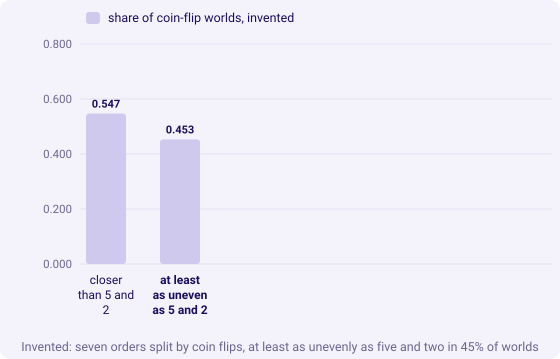

In [5]:
# Invented counts: the debrief deck's invented export, labelled invented wherever they appear.
inv_n, inv_gap = 7, 3            # seven corporate orders, split five and two
closer = sum(comb(inv_n, k) for k in range(inv_n + 1) if abs(2 * k - inv_n) < inv_gap) / 2 ** inv_n
kit.columns(["closer than 5 and 2", "at least as uneven as 5 and 2"],
            [("share of coin-flip worlds, invented", [closer, 1 - closer])],
            fmt=lambda v: f"{v:.3f}", lit=(1,), width=560,
            title=f"Invented: seven orders split by coin flips, at least as unevenly as five and two in {1 - closer:.0%} of worlds")

**Your turn.** Count this file's corporate orders in each quarter and run the same coin flips on
them. Type these lines into the empty cell below and run it:

```python
print("corporate orders:", b1["orders"], "in Q1 and", b2["orders"], "in Q2")
gap = abs(b1["orders"] - b2["orders"])
share = sum(comb(n, k) for k in range(n + 1) if abs(2 * k - n) >= gap) / 2 ** n
print(f"coin flips split {n} orders at least that unevenly in {share:.1%} of worlds")
```

Then write the corporate line of your note as counts: the orders in each quarter, then the rupees.

**The fix, and what it changes.** The corporate fall goes into the note as counts, the orders in each
quarter from your turn above, beside the Rs 17,10,000 it carries. Its action is a question to
whoever owns those accounts about why fewer corporate orders came in, which costs a phone call. The
lead moves to the branch that moved on enough orders to read.

## The options

How does a team choose which finding leads? Four ways, each sized below on the clean tree: the claim
it leads with, the orders behind that claim, how often chance alone produces it, and the analyst
minutes it costs at the lab brief's pace. Option D is run, not described: one test per segment, each
on that segment's own customers' two quarters.

| Option | How it picks the lead |
|---|---|
| A. The biggest rupee move | Whatever moved most in rupees leads |
| B. The total, unsplit | The quarter's change leads and the split is left out |
| C. Count before rate | Every rate carries its order count; a rate on fewer than about thirty orders goes to the caveat as counts, and the lead is the branch that moved on enough orders and survives one test |
| D. Test everything | A test on every segment, and the smallest p-value leads |

option,leads with,orders behind it,chance alone,analyst minutes
A. biggest rupee move,Business -29.2%,fewer than thirty,more than half of coin-flip worlds,5
"B. the total, unsplit",revenue -28.5%,197,not asked,2
C. count before rate,"Retail-Core revenue per order -17.1%, Rs 15,400",88,"0.006, each customer's quarters flipped",15
D. test every segment,"Retail-Core, the smallest of four p-values",fewer than thirty to 88,"0.006, with a 0.19 chance that one of four looks real by luck",45


segment,revenue change,"p, each customer's quarters flipped, 2,000 times"
Retail-Core,-17.1%,0.006
Retail-Plus,+1.5%,0.792
Student,+11.7%,0.271
Business,-29.2%,0.443


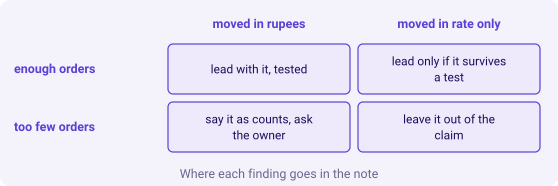

In [6]:
def members_of(seg):
    """Each customer of a segment with their own Q1 and Q2 orders, in customer order."""
    per = {}
    for r in clean:
        if r["segment"] == seg:
            per.setdefault(r["customer_id"], {"Q1": [], "Q2": []})[r["quarter"]].append(r["amount"])
    return dict(sorted(per.items()))


def flipped_change(per, swaps, basket=True):
    """The segment's change from Q1 to Q2 with the swapped customers' two quarters exchanged."""
    q1r = q1n = q2r = q2n = 0
    for v, s in zip(per.values(), swaps):
        a, b = (v["Q2"], v["Q1"]) if s else (v["Q1"], v["Q2"])
        q1r, q1n, q2r, q2n = q1r + sum(a), q1n + len(a), q2r + sum(b), q2n + len(b)
    return change(q1r / q1n, q2r / q2n) if basket else change(q1r, q2r)


def paired_test(seg, basket=True, flips=2000, seed=7):
    """Flip each customer's two quarters at random; the share of worlds as extreme, either way."""
    per = members_of(seg)
    observed = flipped_change(per, [False] * len(per), basket)
    rng = random.Random(seed)
    worlds = [flipped_change(per, [rng.random() < 0.5 for _ in per], basket) for _ in range(flips)]
    return observed, worlds, sum(1 for w in worlds if abs(w) >= abs(observed) - 1e-9) / flips


core = [r for r in clean if r["segment"] == "Retail-Core"]
obs_core, worlds_core, p_core = paired_test("Retail-Core")
four = [(s, *paired_test(s, basket=False)[::2]) for s in SEGS]
false_alarm = 1 - 0.95 ** 4
lead_d = min(four, key=lambda f: f[2])
split_share = sum(comb(n, k) for k in range(n + 1) if abs(2 * k - n) >= abs(b1["orders"] - b2["orders"])) / 2 ** n
kit.table(["option", "leads with", "orders behind it", "chance alone", "analyst minutes"], [
    ("A. biggest rupee move", f"Business {change(b1['rev'], b2['rev']):+.1f}%", "fewer than thirty",
     "more than half of coin-flip worlds" if split_share > 0.5 else "under half of coin-flip worlds", 5),
    ("B. the total, unsplit", f"revenue {change(ctl('Q1')[0], ctl('Q2')[0]):+.1f}%", ctl("Q1")[1] + ctl("Q2")[1],
     "not asked", 2),
    ("C. count before rate", f"Retail-Core revenue per order {obs_core:+.1f}%, "
     f"{kit.rupees(T['Q1', 'Retail-Core']['rev'] - T['Q2', 'Retail-Core']['rev'])}", len(core),
     f"{p_core:.3f}, each customer's quarters flipped", 15),
    ("D. test every segment", f"{lead_d[0]}, the smallest of four p-values", f"fewer than thirty to {len(core)}",
     f"{lead_d[2]:.3f}, with a {false_alarm:.2f} chance that one of four looks real by luck", 45),
], caption="Four ways to choose the lead, sized on the clean tree")
kit.table(["segment", "revenue change", "p, each customer's quarters flipped, 2,000 times"],
          [(s, f"{o:+.1f}%", f"{p:.3f}") for s, o, p in four], caption="Option D, run: one test per segment")
kit.matrix(["enough orders", "too few orders"], ["moved in rupees", "moved in rate only"],
           [["lead with it, tested", "lead only if it survives a test"],
            ["say it as counts, ask the owner", "leave it out of the claim"]],
           title="Where each finding goes in the note")

In [7]:
kit.check("Retail-Core's basket rests on more than thirty orders", len(core) > 30, f"{len(core)} orders")
kit.check("Retail-Core's fall is one chance rarely produces on its customers' own quarters", p_core < 0.05,
          f"p = {p_core:.3f}")
kit.check("testing every segment turns up no second finding under 0.05", sum(1 for f in four if f[2] < 0.05) == 1)

**The best-fit call.** C. It costs about fifteen minutes and one test, and it leads with a finding
that rests on 88 orders and that came up as large, in either direction, in only 12 of 2,000 worlds
where each Retail-Core customer's two quarters were swapped at random. It is small in rupees, Rs
15,400 of the fall, about 0.9 percent of it, so it leads among consumers as the one move on enough
orders to test, while the corporate Rs 17,10,000 sits beside it in the claim as counts. A leads on
too few orders to call a trend. B hides the one thing Meera most needs, that 99 percent of the fall
is the corporate book. D, run here, finds the same lead at three times the minutes, and it spent four
tests to do it: with four tests at 0.05 the chance that at least one looks real by luck is about 19
percent, so on another file D leads with a fluke about one time in five.

**What would change the call.** A question about accounts rather than rates: if Meera asked "what
happened to our corporate revenue?", the lead is the corporate fall, said as counts, with the
accounts named by their owner. A corporate book of hundreds of orders a quarter would let its rate
lead. And a second quarter of the same move in Business would turn a phone call into a trend worth
testing.

## 3. The branch that moved, tested on each customer's own two quarters

Retail-Core keeps its 30 customers and orders about 1.47 times each in both quarters, while its
revenue per order falls 17.1 percent. The claim is about the same 30 customers in both quarters, so
the fair test keeps each customer's own two quarters together. In a world where the quarter made no
difference, each customer's Q1 and Q2 are as likely either way round, so the test swaps them at
random for each customer, recomputes Retail-Core's revenue per order, and counts the worlds with a
change at least as large. The fall was found by looking at the tree, so a rise of that size counts
as well: the note reports both directions.

**Predict before you run.** Where does the real change sit among 2,000 worlds with each customer's
quarters flipped at random?

- a) In the middle of the pile.
- b) At the edge: about a dozen worlds are as extreme.
- c) Beyond every flipped world.
- d) The test cannot run, since some customers ordered twice in a quarter.

Retail-Core revenue per order -17.1%; 12 of 2,000 flipped worlds as large either way, p = 0.0060; counted one way, 0.0010


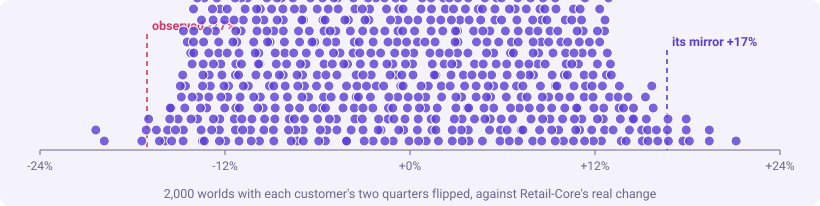

In [8]:
one_way = sum(1 for w in worlds_core if w <= obs_core + 1e-9) / 2000
print(f"Retail-Core revenue per order {obs_core:+.1f}%; {round(p_core * 2000)} of 2,000 flipped worlds as large "
      f"either way, p = {p_core:.4f}; counted one way, {one_way:.4f}")
kit.strip(worlds_core, markers=[("observed", obs_core, "bad"), ("its mirror", -obs_core, "plain")], lo=-24, hi=24,
          fmt=lambda v: f"{v:+.0f}%",
          title="2,000 worlds with each customer's two quarters flipped, against Retail-Core's real change")
kit.check("Retail-Core's customers and frequency hold while its basket falls",
          T["Q1", "Retail-Core"]["customers"] == T["Q2", "Retail-Core"]["customers"]
          and abs(T["Q1", "Retail-Core"]["freq"] - T["Q2", "Retail-Core"]["freq"]) < 0.01)

**What happened.** The answer is b. Only 12 of 2,000 flipped worlds show a change as large as
Retail-Core's, in either direction: p = 0.006, a share of chance-only worlds, never the chance the
finding is wrong. Counted one way, a fall at least as large, it is 0.001, the number a note would
quote only if the fall had been predicted before the data was seen; it was found in the tree, so the
note reports both directions. The share wobbles at 2,000 flips, and at 20,000 it settles near 0.004.

**A different question, a different test.** "Did Retail-Core's basket move differently from
Retail-Plus's?" compares two groups of different customers. There the fair test shuffles the segment
label across whole customers, each carrying all their orders with them, and asks how often a gap as
large as the real one turns up.

In [9]:
plus = [r for r in clean if r["segment"] == "Retail-Plus"]


def basket_change(rs):
    a = [r["amount"] for r in rs if r["quarter"] == "Q1"]
    b = [r["amount"] for r in rs if r["quarter"] == "Q2"]
    return change(sum(a) / len(a), sum(b) / len(b))


gap = basket_change(core) - basket_change(plus)
groups = {}
for r in core + plus:
    groups.setdefault(r["customer_id"], []).append(r)
ids = sorted(groups)
n_core = len({r["customer_id"] for r in core})
rng = random.Random(7)
between = []
for _ in range(2000):
    m = ids[:]
    rng.shuffle(m)
    between.append(basket_change([r for c in m[:n_core] for r in groups[c]])
                   - basket_change([r for c in m[n_core:] for r in groups[c]]))
p_between = sum(1 for g in between if abs(g) >= abs(gap)) / 2000
kit.table(["the question", "the fair test", "p, both directions"], [
    ("did Retail-Core's revenue per order fall?", "each customer's two quarters flipped", f"{p_core:.4f}"),
    ("did it move differently from Retail-Plus's?", "segment label shuffled across whole customers", f"{p_between:.4f}")],
    caption=f"Two questions about one finding; the gap to Retail-Plus is {gap:+.1f} points")
kit.check("both fair tests put the finding outside what chance usually does", p_core < 0.05 and p_between < 0.05)

the question,the fair test,"p, both directions"
did Retail-Core's revenue per order fall?,each customer's two quarters flipped,0.0060
did it move differently from Retail-Plus's?,segment label shuffled across whole customers,0.0195


**The note, with the right lead.** Claim: booked revenue fell 28.5 percent, Rs 60,48,000 to Rs
43,25,480; Rs 17,10,000 of it is the corporate book, and among consumers the branch that moved is
Retail-Core's revenue per order, down 17.1 percent with its 30 customers and their frequency
unchanged. Evidence: both quarters reconcile to Finance's control totals; with each Retail-Core
customer's two quarters flipped at random, a change this large in either direction came up in 12 of
2,000 worlds, p = 0.006. Caveat: the corporate move rests on too few orders to call a trend, and the
note gives its count in each quarter. Action: ask the corporate account owner why fewer corporate
orders came in, and open Retail-Core's basket (items per order and price per item) before any spend.

## A second route: customer by customer

The flips compare the segment's average. A second route reads each customer on their own: of
Retail-Core's customers who ordered in both quarters, how many saw their own average order fall? If
the fall is real and broad, most of them should, and a sign test says how often coin flips alone
would split the customers at least that unevenly.

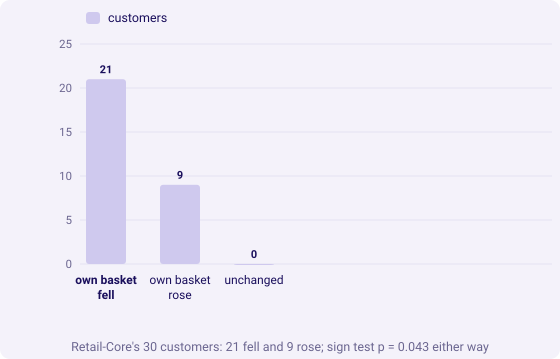

In [10]:
per = members_of("Retail-Core")
fell = sum(1 for v in per.values() if sum(v["Q2"]) / len(v["Q2"]) < sum(v["Q1"]) / len(v["Q1"]))
rose = sum(1 for v in per.values() if sum(v["Q2"]) / len(v["Q2"]) > sum(v["Q1"]) / len(v["Q1"]))
moved = fell + rose
sign_p = 2 * sum(comb(moved, k) for k in range(min(fell, rose) + 1)) / 2 ** moved
kit.columns(["own basket fell", "own basket rose", "unchanged"], [("customers", [fell, rose, len(per) - moved])],
            lit=(0,), width=560,
            title=f"Retail-Core's {len(per)} customers: {fell} fell and {rose} rose; sign test p = {sign_p:.3f} either way")
kit.check("most customers who ordered in both quarters saw their own basket fall", fell > len(per) / 2,
          f"{fell} of {len(per)}")
kit.check("the sign test puts the split outside what coin flips usually do", sign_p < 0.05, f"p = {sign_p:.3f}")
kit.check("the second route points the same way as the flips", (fell > rose) == (obs_core < 0))

**When to switch routes.** The flips say whether the segment's change is bigger than chance; the
customer count says whether it is broad or carried by a few people. When the two disagree, a handful
of customers moved the average, and the note says so. The sign test uses only the direction of each
customer's change, never its size, which is why its p of 0.043 sits above the flips' 0.006.

> **Kavya's review.** Say the count before the rate, every time: the orders in each quarter, then
> the percentage. "Down 29 percent" alone is a headline, and Marketing will take it apart with one
> question.

### In the interview

**[S] Tell me about an analysis you did: what did you find, and how sure are you?** "On a two-quarter
export, revenue fell 28.5 percent after I reconciled it to Finance's control totals. Almost all of it
was the corporate book, on too few orders to call a trend, which I reported as counts and passed to
the account owner. The finding I led with was Retail-Core's revenue per order, down 17.1 percent on
88 orders with customers and frequency flat. The same 30 customers were in both quarters, so I tested
it by flipping each customer's two quarters at random: p = 0.006 counting either direction, and 21 of
the 30 saw their own basket fall. My caveat was the corporate book's count."

**[D] A stakeholder attacks your caveat in front of the room.** "I restate the claim with its count,
bound what the data can say, and offer the test that would settle it with its size and time. For the
corporate book: a handful of orders cannot tell a trend from an account or two pausing; a call to the
account owner settles which it is by Monday."

**The design question: four segments moved; which do you test?** "One: the branch the tree says moved
on enough orders to read, tested on its own customers' two quarters. Testing all four at 0.05 gives
about a one-in-five chance that something looks real by luck, and a test on a handful of orders cannot
say anything a count does not."

### Depth: the tests that break the pairing, and the typical order

Two tests a hurried analyst reaches for split what belongs together. Pooling the customers' Q1 and
Q2 figures and dealing the quarter labels at random treats a customer's own two quarters as two
strangers; shuffling segment labels across single orders splits one customer's orders between the
groups. Either can move p either way. On this file both come out larger than the fair test's,
because each customer's own change from Q1 to Q2 is steadier than the spread between customers, and
a test that splits the pair throws that steadiness away. On a file where the question compares
groups and a customer's orders are alike, splitting them most often makes p too small instead,
because correlated orders count as extra evidence. The cell below runs each fair test beside its
hurried twin, on the same measure.

In [11]:
r1 = [sum(v["Q1"]) for v in per.values()]
r2 = [sum(v["Q2"]) for v in per.values()]
real = sum(r1) / len(r1) - sum(r2) / len(r2)
rng = random.Random(7)
pool, dealt = r1 + r2, []
for _ in range(2000):
    rng.shuffle(pool)
    dealt.append(sum(pool[:len(r1)]) / len(r1) - sum(pool[len(r1):]) / len(r2))
p_pooled = sum(1 for g in dealt if abs(g) >= abs(real) - 1e-9) / 2000
p_pooled_one = sum(1 for g in dealt if g >= real - 1e-9) / 2000
rng = random.Random(7)
d = [b - a for a, b in zip(r1, r2)]
p_flip_rev = sum(1 for _ in range(2000)
                 if abs(sum(x if rng.random() < 0.5 else -x for x in d)) >= abs(sum(d)) - 1e-9) / 2000
both_rows = core + plus
rng = random.Random(7)
ext = 0
for _ in range(2000):
    idx = list(range(len(both_rows)))
    rng.shuffle(idx)
    a = [both_rows[i] for i in idx[:len(core)]]
    b = [both_rows[i] for i in idx[len(core):]]
    ext += abs(basket_change(a) - basket_change(b)) >= abs(gap)
p_orders = ext / 2000
amounts = sorted(r["amount"] for r in clean)
kit.table(["measure", "the test", "what it keeps together", "p, both directions"], [
    ("revenue per customer, Q1 to Q2", "each customer's two quarters flipped", "each customer's own pair",
     f"{p_flip_rev:.4f}"),
    ("revenue per customer, Q1 to Q2", "Q1 and Q2 figures pooled and dealt", "nothing",
     f"{p_pooled:.4f} ({p_pooled_one:.4f} one way)"),
    ("revenue per order, gap to Retail-Plus", "segment label across whole customers", "each customer's orders",
     f"{p_between:.4f}"),
    ("revenue per order, gap to Retail-Plus", "segment label across single orders", "nothing", f"{p_orders:.4f}")],
    caption="Each fair test beside the hurried twin that splits the pair")
kit.table(["measure", "value"], [("mean order, clean", kit.rupees(statistics.mean(amounts))),
                                 ("median order, clean", kit.rupees(statistics.median(amounts)))],
          caption="The typical order")
kit.check("splitting the pairs pushes both verdicts past 0.05 on this file",
          p_pooled > 0.05 > p_flip_rev and p_orders > 0.05 > p_between)

measure,the test,what it keeps together,"p, both directions"
"revenue per customer, Q1 to Q2",each customer's two quarters flipped,each customer's own pair,0.0015
"revenue per customer, Q1 to Q2",Q1 and Q2 figures pooled and dealt,nothing,0.0765 (0.0325 one way)
"revenue per order, gap to Retail-Plus",segment label across whole customers,each customer's orders,0.0195
"revenue per order, gap to Retail-Plus",segment label across single orders,nothing,0.0755


measure,value
"mean order, clean","Rs 52,657"
"median order, clean","Rs 2,120"


The mean order is pulled up by the corporate orders, so it describes no order anybody placed; the
median is the typical one, and the mean belongs in anything that must reconcile.

In [12]:
kit.check_summary()